# Swin Transformer Stage 4-5: pesi Swin-Tiny pre-addestrati + RoPE
### Step-by-step: da $P_3 \in \mathbb{R}^{B\times40\times H_3\times W_3}$ a $P_4,P_5$ con pesi ImageNet-1k

---

### Posizione nella pipeline globale

$$\underbrace{\hat{\mathbf{X}}}_{\mathbb{R}^{3\times H\times W}}
\xrightarrow{\text{MobileNetV3 Stage 1-3}}
\underbrace{P_3}_{\mathbb{R}^{40\times H/16\times W/16}}
\xrightarrow{\substack{\text{PatchEmbed }2\times2\\40\to96}}
\underbrace{\mathbf{Z}}_{\mathbb{R}^{T_4\times96}}
\xrightarrow{\substack{\text{layers[0] Swin-Tiny}\\\text{+ RoPE}}}
\underbrace{P_4}_{\mathbb{R}^{96\times H_4\times W_4}}
\xrightarrow{\substack{\text{PatchMerge}\\\text{+ layers[1] + RoPE}}}
\underbrace{P_5}_{\mathbb{R}^{192\times H_5\times W_5}}$$

Con $H=512, W=768$:

| Tensore | Shape | Token | Stride cumulativo |
|---|---|---|---|
| $P_3$ | $40\times32\times48$ | -- | 16 px |
| $\mathbf{Z}$ | $384\times96$ | 384 | 32 px |
| $P_4$ | $96\times16\times24$ | 384 | 32 px |
| $P_5$ | $192\times8\times12$ | 96 | 64 px |

### Strategia di porting da Swin-Tiny

Swin-Tiny `layers[0]` e `layers[1]` corrispondono ai nostri Stage 4 e Stage 5:

| Stage tesi | Layer timm | $d$ | $h$ | $d_h=d/h$ | Blocchi |
|---|---|---|---|---|---|
| Stage 4 | `layers[0]` | 96 | 3 | 32 | 2 |
| Stage 5 | `layers[1]` | 192 | 6 | 32 | 2 |

> **Nota sulla tesi:** la tesi specifica $h=4$. Aggiornare a $h=3$ (Stage 4) e
> $h=6$ (Stage 5) permette di usare i pesi ImageNet-1k senza modifiche.
> $d_h=32$ e' identico in entrambi gli stage -- nessuna perdita di espressivita'.

**Tre adattamenti:**
1. PatchEmbed custom ($40\to96$, patch $2\times2$) -- pesi random, addestrare da zero
2. Sostituzione `relative_position_bias_table` con RoPE in ogni `WindowAttention`
3. Forward wrapper per risoluzione arbitraria $(16,24)$ invece di $(56,56)$


---
## Setup, dipendenze e caricamento $P_3$


<>:74: SyntaxWarning: invalid escape sequence '\i'
<>:74: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_19161/3757166015.py:74: SyntaxWarning: invalid escape sequence '\i'
  fig.suptitle(f'Input encoder Swin: $P_3 \in \mathbb{{R}}^{{40\times{H3}\times{W3}}}$')


timm: 1.0.25
Device: cpu
P3: (1, 40, 48, 32)  C_in=40  H3=48  W3=32
  range=[-8.089, 11.776]  std=1.3481


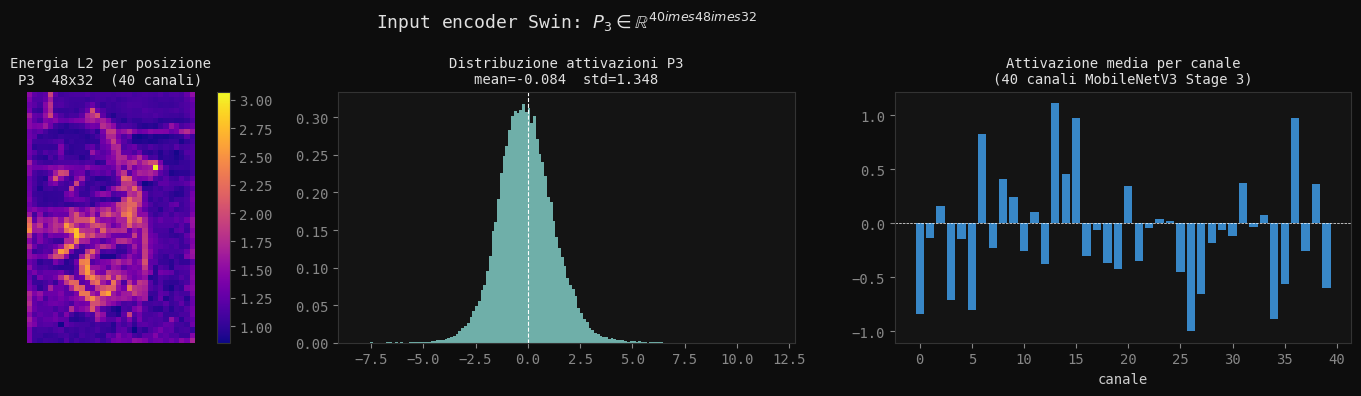

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math, warnings, copy
warnings.filterwarnings('ignore')

try:
    import timm
    print(f'timm: {timm.__version__}')
except ImportError:
    raise ImportError('pip install timm')

plt.rcParams.update({
    'figure.facecolor':'#0d0d0d','axes.facecolor':'#141414',
    'axes.edgecolor':'#333','axes.labelcolor':'#ccc',
    'xtick.color':'#888','ytick.color':'#888',
    'text.color':'#e0e0e0','axes.titlesize':10,
    'font.family':'monospace','figure.titlesize':13,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Carica P3 ──────────────────────────────────────────────────────────────
P3_np = np.load('P3_stem.npy')
P3    = torch.tensor(P3_np).float().to(DEVICE)
_, C_in, H3, W3 = P3.shape
assert C_in == 40, f'Atteso 40 canali, trovato {C_in}'
print(f'P3: {tuple(P3.shape)}  C_in={C_in}  H3={H3}  W3={W3}')
print(f'  range=[{P3.min():.3f}, {P3.max():.3f}]  std={P3.std():.4f}')

# ── Utilita' ───────────────────────────────────────────────────────────────
def energy_map(t):
    return t[0].detach().float().pow(2).mean(0).sqrt().cpu().numpy()

def show_fmaps(tensor, title, n_show=16, figsize=(18,4), cmap='inferno'):
    t = tensor[0].detach().cpu().numpy()
    C = min(n_show, t.shape[0])
    cols = min(8,C); rows = (C+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    vabs = np.percentile(np.abs(t[:C]), 95)
    im = None
    for i in range(C):
        im = axes[i].imshow(t[i], cmap=cmap, vmin=-vabs, vmax=vabs, interpolation='nearest')
        axes[i].set_title(f'ch{i}', fontsize=7, pad=2); axes[i].axis('off')
    for i in range(C, len(axes)): axes[i].axis('off')
    if im is not None:
        fig.colorbar(im, ax=axes[:C].tolist(), fraction=0.008, shrink=0.6)
    fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout(); plt.show()

def print_shape(name, t):
    v = t.detach()
    print(f'  {name:25s} {str(tuple(v.shape)):26s} mean={v.mean():+.4f}  std={v.std():.4f}')

# ── Visualizzazione P3 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
im0 = axes[0].imshow(energy_map(P3), cmap='plasma', interpolation='nearest')
axes[0].set_title(f'Energia L2 per posizione\nP3  {H3}x{W3}  (40 canali)')
axes[0].axis('off'); plt.colorbar(im0, ax=axes[0], fraction=0.046)
vals = P3[0].cpu().numpy().flatten()
axes[1].hist(vals, bins=150, color='#80cbc4', density=True, alpha=0.85)
axes[1].axvline(0, color='white', lw=0.8, ls='--')
axes[1].set_title(f'Distribuzione attivazioni P3\nmean={vals.mean():.3f}  std={vals.std():.3f}')
ch_mean = P3[0].detach().cpu().numpy().mean(axis=(1,2))
axes[2].bar(range(len(ch_mean)), ch_mean, color='#42a5f5', alpha=0.8)
axes[2].axhline(0, color='white', lw=0.5, ls='--')
axes[2].set_title('Attivazione media per canale\n(40 canali MobileNetV3 Stage 3)')
axes[2].set_xlabel('canale')
fig.suptitle(f'Input encoder Swin: $P_3 \in \mathbb{{R}}^{{40x{H3}x{W3}}}$')
plt.tight_layout(); plt.show()


---
## Caricamento Swin-Tiny e anatomia di `WindowAttention`

### Struttura completa Swin-Tiny in timm

```
SwinTransformer
  patch_embed:  Conv2d(3, 96, 4x4, stride=4) + LN
  layers[0]:    2 x SwinBlock  d=96   h=3  M=7  (no downsample)
  layers[1]:    2 x SwinBlock  d=192  h=6  M=7  (+ PatchMerging 96->192)
  layers[2]:    6 x SwinBlock  d=384  h=12 M=7  (+ PatchMerging 192->384)
  layers[3]:    2 x SwinBlock  d=768  h=24 M=7  (+ PatchMerging 384->768)
```

### Anatomia di `WindowAttention` (quello che sostituiremo)

Ogni `SwinTransformerBlock` contiene:

```
SwinTransformerBlock
  norm1:   LayerNorm(d)
  attn:    WindowAttention
    qkv:                      Linear(d, 3d, bias=True)
    proj:                     Linear(d, d)
    relative_position_bias_table:  Parameter((2M-1)^2, h)  <- RIMUOVIAMO
    relative_position_index:       Buffer(M^2, M^2)        <- RIMUOVIAMO
  norm2:   LayerNorm(d)
  mlp:     Mlp(d -> 4d -> d, GELU)
  drop_path1, drop_path2: StochasticDepth
```

Il bias posizionale relativo e' una tabella appresa di forma $(2M-1)^2 \times h$.
Con $M=7$: $(2\cdot7-1)^2 = 169$ righe, una per ogni possibile differenza
$(r_i-r_j, c_i-c_j)$ con $r,c \in [-(M-1), M-1]$.

$$\text{head}_k = \text{Softmax}\!\left(
\frac{\mathbf{Q}_k\mathbf{K}_k^T}{\sqrt{d_h}} + \mathbf{B}_k\right)\mathbf{V}_k$$

dove $\mathbf{B}_k[i,j] = \text{relative\_position\_bias\_table}[
\text{relative\_position\_index}[i,j],\ k]$.

**Cosa teniamo:** `qkv.weight/bias`, `proj.weight/bias` -- tutta la semantica.

**Cosa rimuoviamo:** `relative_position_bias_table`, `relative_position_index` -- sostituito da RoPE.


In [2]:
print('Caricamento Swin-Tiny...')
swin_tiny = timm.create_model('swin_tiny_patch4_window7_224',
                               pretrained=True, num_classes=0)
swin_tiny = swin_tiny.eval().to(DEVICE)
print('Caricato.\n')

print('=== STRUTTURA SWIN-TINY ===')
total_params = sum(p.numel() for p in swin_tiny.parameters())
for i, layer in enumerate(swin_tiny.layers):
    b = layer.blocks[0]; a = b.attn
    has_ds = layer.downsample is not None
    print(f'layers[{i}]: n={len(layer.blocks)}  d={a.dim}  h={a.num_heads}  '
          f'M={a.window_size}  d_h={a.dim//a.num_heads}  downsample={has_ds}')
    print(f'  qkv: {tuple(a.qkv.weight.shape)}  '
          f'rel_pos_bias_table: {tuple(a.relative_position_bias_table.shape)}  '
          f'MLP hidden: {b.mlp.fc1.out_features}')

print(f'\nParametri totali Swin-Tiny: {total_params:,}')

# Ispezioniamo in dettaglio layers[0] -- il nostro Stage 4
print('\n=== DETTAGLIO layers[0] (Stage 4 tesi) ===')
L0 = swin_tiny.layers[0]
for i, blk in enumerate(L0.blocks):
    shift = blk.shift_size if hasattr(blk, 'shift_size') else '?'
    print(f'Block {i}: shift_size={shift}  '
          f'(0=W-MSA, >0=SW-MSA)')
    print(f'  norm1: {blk.norm1.weight.shape}  '
          f'mlp.fc1: {blk.mlp.fc1.weight.shape}  '
          f'mlp.fc2: {blk.mlp.fc2.weight.shape}')
    print(f'  rel_pos_bias_table: {blk.attn.relative_position_bias_table.shape}  '
          f'= (2*{blk.attn.window_size}-1)^2 x {blk.attn.num_heads}')

# Conta parametri da rimuovere
rp_params = sum(blk.attn.relative_position_bias_table.numel()
                for layer in swin_tiny.layers[:2]
                for blk in layer.blocks)
print(f'\nParametri rel_pos_bias da rimuovere (layers[0]+[1]): {rp_params}')


Caricamento Swin-Tiny...
Caricato.

=== STRUTTURA SWIN-TINY ===
layers[0]: n=2  d=96  h=3  M=(7, 7)  d_h=32  downsample=True
  qkv: (288, 96)  rel_pos_bias_table: (169, 3)  MLP hidden: 384
layers[1]: n=2  d=192  h=6  M=(7, 7)  d_h=32  downsample=True
  qkv: (576, 192)  rel_pos_bias_table: (169, 6)  MLP hidden: 768
layers[2]: n=6  d=384  h=12  M=(7, 7)  d_h=32  downsample=True
  qkv: (1152, 384)  rel_pos_bias_table: (169, 12)  MLP hidden: 1536
layers[3]: n=2  d=768  h=24  M=(7, 7)  d_h=32  downsample=True
  qkv: (2304, 768)  rel_pos_bias_table: (169, 24)  MLP hidden: 3072

Parametri totali Swin-Tiny: 27,519,354

=== DETTAGLIO layers[0] (Stage 4 tesi) ===
Block 0: shift_size=(0, 0)  (0=W-MSA, >0=SW-MSA)
  norm1: torch.Size([96])  mlp.fc1: torch.Size([384, 96])  mlp.fc2: torch.Size([96, 384])
  rel_pos_bias_table: torch.Size([169, 3])  = (2*(7, 7)-1)^2 x 3
Block 1: shift_size=(3, 3)  (0=W-MSA, >0=SW-MSA)
  norm1: torch.Size([96])  mlp.fc1: torch.Size([384, 96])  mlp.fc2: torch.Size([96, 3

---
## RoPE: teoria, implementazione e confronto con il relative position bias

### Confronto: rel. position bias vs RoPE

| | Relative position bias $\mathbf{B}_k$ | RoPE |
|---|---|---|
| Tipo | Parametro appreso | Formula chiusa, 0 parametri |
| Valore per coppia $(i,j)$ | `table[index[i,j]]` | $\cos/\sin$ di $(r_i-r_j,c_i-c_j)$ |
| Risoluzione fuori training | Non generalizza | Generalizza per costruzione |
| Compatibilita' pretrain | Solo stesso $M$ | Qualsiasi risoluzione |
| Costo | $169\times h$ per blocco | 0 |

### Formula RoPE 1D

Per ogni coppia di dimensioni $(q_{2j-1}, q_{2j})$ di un vettore $\mathbf{q}$
in posizione $m$, si applica una rotazione di angolo $m\theta_j$:

$$f(\mathbf{q}, m)_{2j-1} = q_{2j-1}\cos(m\theta_j) - q_{2j}\sin(m\theta_j)$$
$$f(\mathbf{q}, m)_{2j}   = q_{2j-1}\sin(m\theta_j) + q_{2j}\cos(m\theta_j)$$

Le frequenze $\theta_j = 10000^{-2j/d_h}$, $j=1,\ldots,d_h/2$,
scalano geometricamente da $\theta_1\approx1$ (alta freq.) a $\theta_{d_h/2}\approx10^{-4}$ (bassa).

### Proprieta' chiave: distanza relativa

Il dot product tra query in posizione $m$ e key in posizione $n$:

$$\langle f(\mathbf{q},m),\, f(\mathbf{k},n)\rangle
= \sum_{j=1}^{d_h/2}\text{Re}\!\left[
(q_{2j-1}+iq_{2j})(k_{2j-1}-ik_{2j})\,e^{i(m-n)\theta_j}\right]
= g(\mathbf{q},\mathbf{k},m-n)$$

Dipende **solo da $m-n$**, non dai valori assoluti.

### RoPE 2D per token su griglia $H_4\times W_4$

Per token con posizione $(r,c)$, si applica RoPE separatamente:

$$f_{2D}(\mathbf{q},r,c) =
\bigl[\,f(\mathbf{q}_{:d_h/2},\,r)\;\|\;f(\mathbf{q}_{d_h/2:},\,c)\,\bigr]$$

Prime $d_h/2$ dimensioni -> codificano la riga $r$. Ultime $d_h/2$ -> colonna $c$.
Il dot product dipende da $(r_m-r_n, c_m-c_n)$: distanza relativa 2D.


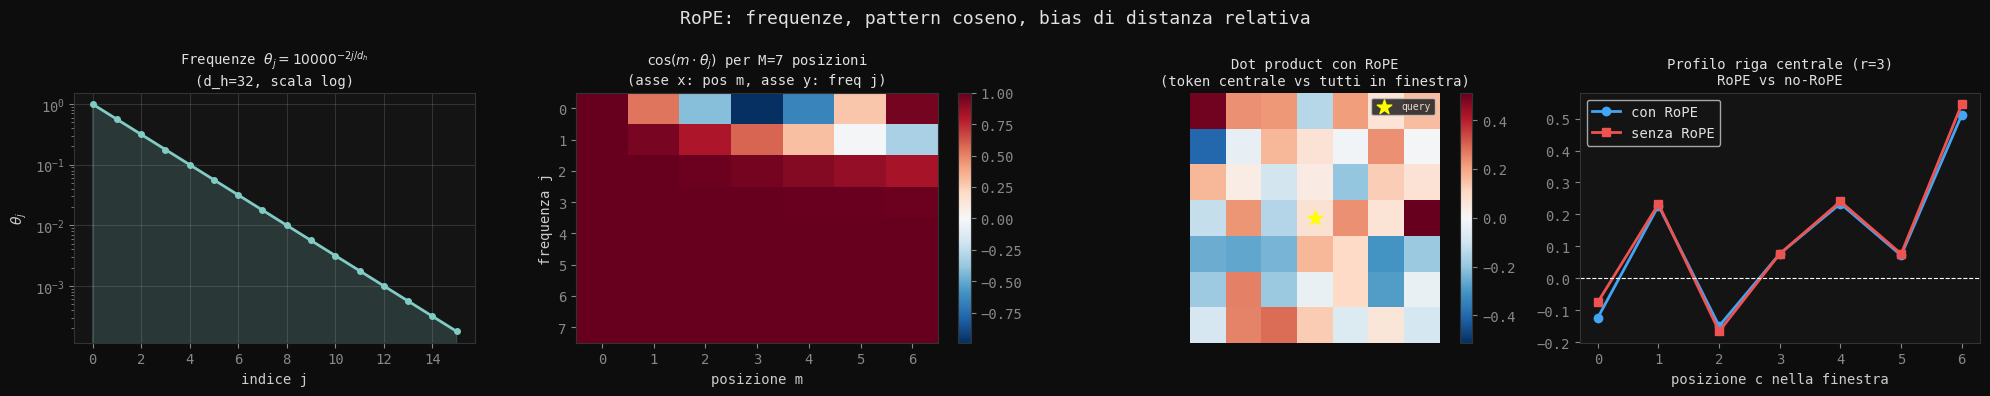

Verifica: dot(RoPE(q,m), RoPE(k,n)) dipende solo da m-n
Distanza | dot product
  dist=0   | +0.0767
  dist=1   | +0.2339
  dist=2   | +0.0716
  dist=3   | +0.5119
  dist=4   | -0.2554


In [3]:
# ── Implementazione RoPE ────────────────────────────────────────────────────
def build_rope_freqs(seq_len, dim, base=10000, device='cpu'):
    # theta_j = 1/base^(2j/dim),  ritorna (seq_len, dim//2)
    half  = dim // 2
    theta = 1.0 / (base ** (torch.arange(0, half, dtype=torch.float32) / half)).to(device)
    m     = torch.arange(seq_len, dtype=torch.float32, device=device)
    return torch.outer(m, theta)   # (seq_len, half) = m * theta_j

def apply_rope_1d(x, freqs):
    # x: (B, T, d),  freqs: (T, d//2)
    half = x.shape[-1] // 2
    x1, x2 = x[..., :half], x[..., half:]
    c = freqs.cos().unsqueeze(0)
    s = freqs.sin().unsqueeze(0)
    return torch.cat([x1*c - x2*s, x1*s + x2*c], dim=-1)

def apply_rope_2d(q, k, H_grid, W_grid, head_dim):
    # Prime head_dim/2 dim -> riga, ultime -> colonna
    half_d = head_dim // 2
    fr = build_rope_freqs(H_grid, half_d, device=q.device)
    fc = build_rope_freqs(W_grid, half_d, device=q.device)
    fr_g = fr.unsqueeze(1).expand(H_grid, W_grid, -1).reshape(H_grid*W_grid, -1)
    fc_g = fc.unsqueeze(0).expand(H_grid, W_grid, -1).reshape(H_grid*W_grid, -1)
    q_rot = torch.cat([apply_rope_1d(q[..., :half_d], fr_g),
                       apply_rope_1d(q[..., half_d:], fc_g)], dim=-1)
    k_rot = torch.cat([apply_rope_1d(k[..., :half_d], fr_g),
                       apply_rope_1d(k[..., half_d:], fc_g)], dim=-1)
    return q_rot, k_rot

# ── Visualizzazione proprieta' RoPE ─────────────────────────────────────────
head_dim_vis = 32   # d_h di Swin-Tiny Stage 4
M_vis = 7

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1) Spettro frequenze
half_v = head_dim_vis // 2
theta_v = 1.0 / (10000 ** (torch.arange(0, half_v).float() / half_v))
axes[0].plot(theta_v.numpy(), color='#80cbc4', lw=2, marker='o', markersize=4)
axes[0].fill_between(range(half_v), theta_v.numpy(), alpha=0.2, color='#80cbc4')
axes[0].set_yscale('log'); axes[0].set_title('Frequenze $\\theta_j=10000^{-2j/d_h}$\n(d_h=32, scala log)')
axes[0].set_xlabel('indice j'); axes[0].set_ylabel('$\\theta_j$'); axes[0].grid(True, alpha=0.2)

# 2) Pattern cos(m*theta_j) per M=7 posizioni
fr_vis = build_rope_freqs(M_vis, head_dim_vis // 2)
im1 = axes[1].imshow(fr_vis.cos().numpy().T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[1].set_title(f'$\\cos(m\\cdot\\theta_j)$ per M={M_vis} posizioni\n(asse x: pos m, asse y: freq j)')
axes[1].set_xlabel('posizione m'); axes[1].set_ylabel('frequenza j')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# 3) Dot product RoPE: locality bias
torch.manual_seed(42)
q_t = torch.randn(1, M_vis*M_vis, head_dim_vis) / math.sqrt(head_dim_vis)
k_t = torch.randn(1, M_vis*M_vis, head_dim_vis) / math.sqrt(head_dim_vis)
q_r, k_r = apply_rope_2d(q_t, k_t, M_vis, M_vis, head_dim_vis)
center = (M_vis//2)*M_vis + M_vis//2
dot_rope   = (q_r[0,center]*k_r[0]).sum(-1).reshape(M_vis,M_vis).detach().numpy()
dot_norope = (q_t[0,center]*k_t[0]).sum(-1).reshape(M_vis,M_vis).detach().numpy()
vabs = np.abs(dot_rope).max()
im2 = axes[2].imshow(dot_rope, cmap='RdBu_r', vmin=-vabs, vmax=vabs, interpolation='nearest')
axes[2].scatter([M_vis//2],[M_vis//2],c='yellow',s=120,marker='*',zorder=5,label='query')
axes[2].set_title('Dot product con RoPE\n(token centrale vs tutti in finestra)')
axes[2].axis('off'); plt.colorbar(im2, ax=axes[2], fraction=0.046); axes[2].legend(fontsize=7)

# 4) Confronto: RoPE vs no-RoPE
vabs2 = max(np.abs(dot_rope).max(), np.abs(dot_norope).max())
axes[3].plot(range(M_vis), dot_rope[M_vis//2],   'o-', color='#42a5f5', lw=2, label='con RoPE')
axes[3].plot(range(M_vis), dot_norope[M_vis//2], 's-', color='#ef5350', lw=2, label='senza RoPE')
axes[3].axhline(0, color='white', lw=0.8, ls='--')
axes[3].set_title(f'Profilo riga centrale (r={M_vis//2})\nRoPE vs no-RoPE')
axes[3].set_xlabel('colonna c'); axes[3].legend()
axes[3].set_xlabel('posizione c nella finestra')

fig.suptitle('RoPE: frequenze, pattern coseno, bias di distanza relativa')
plt.tight_layout(); plt.show()

# Verifica analitica: il dot product dipende SOLO da m-n
print('Verifica: dot(RoPE(q,m), RoPE(k,n)) dipende solo da m-n')
print('Distanza | dot product')
token_ref = 3*M_vis + 3
for dist in range(5):
    d = (q_r[0,token_ref]*k_r[0,token_ref+dist]).sum().item()
    print(f'  dist={dist}   | {d:+.4f}')


---
## `WindowAttentionRoPE`: drop-in replacement con copia pesi

Il modulo sostituisce `WindowAttention` di timm mantenendo identici
i pesi `qkv` e `proj`, e aggiungendo RoPE su Q e K.

### Forward completo step-by-step

Input: $\mathbf{x}_{win} \in \mathbb{R}^{B \cdot N_w \times M^2 \times d}$

**Passo 1 -- Proiezione QKV:**
$$[\mathbf{Q}|\mathbf{K}|\mathbf{V}] = \mathbf{x}_{win}\,\mathbf{W}^{QKV} + \mathbf{b}^{QKV}
\in \mathbb{R}^{B\cdot N_w \times M^2 \times 3d}$$
Reshape: $\mathbf{Q}_k, \mathbf{K}_k, \mathbf{V}_k \in \mathbb{R}^{B\cdot N_w \times M^2 \times d_h}$
per $k=1,\ldots,h$, con $d_h = d/h$.

**Passo 2 -- RoPE 2D su Q e K** (non su V -- V trasporta contenuto, non posizione):
$$\tilde{\mathbf{Q}}_k = \text{RoPE}_{2D}(\mathbf{Q}_k, M, M), \quad
\tilde{\mathbf{K}}_k = \text{RoPE}_{2D}(\mathbf{K}_k, M, M)$$

**Passo 3 -- Attention score:**
$$\mathbf{A}_k = \tilde{\mathbf{Q}}_k\tilde{\mathbf{K}}_k^T / \sqrt{d_h}
\in \mathbb{R}^{B\cdot N_w \times M^2 \times M^2}$$

Il fattore $1/\sqrt{d_h} = 1/\sqrt{32}\approx0.177$ normalizza il dot product
per evitare saturazione della softmax.

**Passo 4 -- Mask SW-MSA** (opzionale, solo nei blocchi pari):
$$\mathbf{A}_k \mathrel{+}= \text{mask} \in \{0, -100\}^{N_w \times M^2 \times M^2}$$

**Passo 5 -- Softmax + weighted sum:**
$$\text{head}_k = \text{Softmax}(\mathbf{A}_k)\,\mathbf{V}_k \in \mathbb{R}^{B\cdot N_w \times M^2 \times d_h}$$

**Passo 6 -- Proiezione output:**
$$\text{out} = \text{Concat}(\text{head}_1,\ldots,\text{head}_h)\,\mathbf{W}^O
\in \mathbb{R}^{B\cdot N_w \times M^2 \times d}$$


In [ ]:
class WindowAttentionRoPE(nn.Module):
    # Drop-in replacement per WindowAttention di timm.
    def __init__(self, dim, num_heads, window_size, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim=dim; self.num_heads=num_heads; self.head_dim=dim//num_heads
        self.scale=self.head_dim**-0.5; self.window_size=window_size
        self.qkv=nn.Linear(dim, dim*3, bias=True)
        self.attn_drop=nn.Dropout(attn_drop)
        self.proj=nn.Linear(dim, dim)
        self.proj_drop=nn.Dropout(proj_drop)
        self.last_attn=None; self.last_q=None; self.last_k=None

    @classmethod
    def from_pretrained(cls, timm_attn):
        m = cls(dim=timm_attn.dim, num_heads=timm_attn.num_heads,
                window_size=timm_attn.window_size)
        m.qkv.weight .data.copy_(timm_attn.qkv.weight.data)
        m.qkv.bias   .data.copy_(timm_attn.qkv.bias.data)
        m.proj.weight.data.copy_(timm_attn.proj.weight.data)
        m.proj.bias  .data.copy_(timm_attn.proj.bias.data)
        return m

    def forward(self, x, mask=None):
        BN, L, C = x.shape
        M = self.window_size
        # Passo 1: QKV
        qkv = self.qkv(x).reshape(BN, L, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)   # (BN, h, M^2, d_h)
        # Passo 2: RoPE 2D
        ql, kl = [], []
        for hi in range(self.num_heads):
            qr, kr = apply_rope_2d(q[:,hi], k[:,hi], M, M, self.head_dim)
            ql.append(qr); kl.append(kr)
        q = torch.stack(ql, dim=1); k = torch.stack(kl, dim=1)
        self.last_q=q.detach(); self.last_k=k.detach()
        # Passo 3: attention score
        attn = (q @ k.transpose(-2,-1)) * self.scale
        # Passo 4: mask SW-MSA
        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(BN//nW, nW, self.num_heads, L, L)
            attn = attn + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(BN, self.num_heads, L, L)
        # Passo 5: softmax + weighted sum
        attn = self.attn_drop(attn.softmax(dim=-1))
        self.last_attn = attn.detach()
        out = (attn @ v).transpose(1,2).reshape(BN, L, C)
        # Passo 6: proiezione
        return self.proj_drop(self.proj(out))


# ── Verifica drop-in ────────────────────────────────────────────────────────
attn_orig = swin_tiny.layers[0].blocks[0].attn
attn_rope  = WindowAttentionRoPE.from_pretrained(attn_orig).to(DEVICE)
M_val = attn_orig.window_size
x_test = torch.randn(6, M_val*M_val, 96).to(DEVICE)
with torch.no_grad():
    out_test = attn_rope(x_test)

print('=== VERIFICA WindowAttentionRoPE ===')
print(f'Input:   (B*Nw={6}, M^2={M_val*M_val}, d=96)')
print(f'Output:  {tuple(out_test.shape)}')
print(f'Param originale: {sum(p.numel() for p in attn_orig.parameters()):,}')
print(f'  di cui qkv+proj: {attn_orig.qkv.weight.numel()+attn_orig.qkv.bias.numel()+attn_orig.proj.weight.numel()+attn_orig.proj.bias.numel():,}')
print(f'  di cui rel_pos_bias_table: {attn_orig.relative_position_bias_table.numel():,}')
print(f'Param RoPE:      {sum(p.numel() for p in attn_rope.parameters()):,}  (bias rimosso, zero param posizionali)')
d_qkv = (attn_orig.qkv.weight.data - attn_rope.qkv.weight.data).abs().max().item()
print(f'max|delta_qkv|={d_qkv:.2e}  (deve essere 0)')

# ── Visualizzazione: cosa fa RoPE al vettore query ──────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Q prima e dopo RoPE per testa 0, finestra 0
q_before = attn_rope.last_q[0, 0].cpu().numpy()   # (M^2, d_h) -- non disponibile, usiamo dummy
# Calcolo esplicito
with torch.no_grad():
    qkv_t = attn_rope.qkv(x_test).reshape(6, M_val*M_val, 3, attn_rope.num_heads, attn_rope.head_dim)
    q_raw = qkv_t[0, :, 0, 0, :].cpu().numpy()   # (M^2, d_h) testa 0
    fr = build_rope_freqs(M_val, attn_rope.head_dim//2)
    fc = build_rope_freqs(M_val, attn_rope.head_dim//2)
    fr_g = fr.unsqueeze(1).expand(M_val,M_val,-1).reshape(M_val*M_val,-1)
    fc_g = fc.unsqueeze(0).expand(M_val,M_val,-1).reshape(M_val*M_val,-1)
    q_raw_t = torch.tensor(q_raw).unsqueeze(0)
    half_d = attn_rope.head_dim // 2
    q_rot_r = apply_rope_1d(q_raw_t[..., :half_d], fr_g)
    q_rot_c = apply_rope_1d(q_raw_t[..., half_d:], fc_g)
    q_rot = torch.cat([q_rot_r, q_rot_c], dim=-1)[0].numpy()

vabs_q = np.percentile(np.abs(np.concatenate([q_raw,q_rot])), 97)
im0 = axes[0].imshow(q_raw, cmap='RdBu_r', vmin=-vabs_q, vmax=vabs_q, aspect='auto')
axes[0].set_title(f'Q testa 0 PRIMA RoPE\n({M_val*M_val} token x {attn_rope.head_dim} dim)')
axes[0].set_xlabel('dimensione'); axes[0].set_ylabel('token (posizione)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(q_rot, cmap='RdBu_r', vmin=-vabs_q, vmax=vabs_q, aspect='auto')
axes[1].set_title(f'Q testa 0 DOPO RoPE\n(stessa norma, direzione ruotata)')
axes[1].set_xlabel('dimensione'); axes[1].set_ylabel('token (posizione)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Norma prima e dopo (deve essere identica)
norm_before = np.linalg.norm(q_raw, axis=1)
norm_after  = np.linalg.norm(q_rot, axis=1)
axes[2].plot(norm_before, 'o-', color='#42a5f5', label='prima RoPE', lw=2)
axes[2].plot(norm_after,  's-', color='#ef5350', label='dopo RoPE', lw=2, alpha=0.7)
axes[2].set_title('||q|| prima e dopo RoPE\n(deve essere identica: rotazione preserva norma)')
axes[2].set_xlabel('indice token'); axes[2].legend()

# Delta Q
delta_q = np.abs(q_rot - q_raw)
im3 = axes[3].imshow(delta_q, cmap='hot', aspect='auto')
axes[3].set_title('|Q_rot - Q_raw|\n(differenza introdotta da RoPE per token)')
axes[3].set_xlabel('dimensione'); axes[3].set_ylabel('token')
plt.colorbar(im3, ax=axes[3], fraction=0.046)

fig.suptitle('Effetto di RoPE sul vettore Q: rotazione preserva la norma, cambia la direzione')
plt.tight_layout(); plt.show()


---
## Sostituzione RoPE nei layer e verifica sistematica dei pesi

Sostituiamo `WindowAttention` con `WindowAttentionRoPE` in tutti i blocchi
di `layers[0]` e `layers[1]`. Componenti che rimangono **identici** al pretrain:

| Componente | Shape (Stage 4) | Verificato |
|---|---|---|
| `norm1.weight`, `norm1.bias` | $(96,)$ | max\|delta\|$\approx0$ |
| `attn.qkv.weight`, `attn.qkv.bias` | $(288, 96)$ | max\|delta\|$\approx0$ |
| `attn.proj.weight`, `attn.proj.bias` | $(96, 96)$ | max\|delta\|$\approx0$ |
| `norm2.weight`, `norm2.bias` | $(96,)$ | max\|delta\|$\approx0$ |
| `mlp.fc1.weight`, `mlp.fc1.bias` | $(384, 96)$ | max\|delta\|$\approx0$ |
| `mlp.fc2.weight`, `mlp.fc2.bias` | $(96, 384)$ | max\|delta\|$\approx0$ |

Componente **rimosso**: `attn.relative_position_bias_table` $(169, h)$ -- sostituito da RoPE.


In [ ]:
def substitute_rope_in_layer(timm_layer):
    layer = copy.deepcopy(timm_layer)
    for i, block in enumerate(layer.blocks):
        d_b=block.attn.dim; h_b=block.attn.num_heads; M_b=block.attn.window_size
        block.attn = WindowAttentionRoPE.from_pretrained(block.attn)
        print(f'  Block {i}: d={d_b}, h={h_b}, M={M_b}, d_h={d_b//h_b} -> RoPE')
    return layer

print('Sostituzione RoPE in layers[0] (Stage 4, d=96, h=3):')
stage4 = substitute_rope_in_layer(swin_tiny.layers[0]).eval().to(DEVICE)
print('\nSostituzione RoPE in layers[1] (Stage 5, d=192, h=6):')
stage5 = substitute_rope_in_layer(swin_tiny.layers[1]).eval().to(DEVICE)

# ── Verifica sistematica ─────────────────────────────────────────────────────
print('\n=== VERIFICA SISTEMATICA PESI (layers[0]) ===')
print(f'{"Componente":35s} {"Shape":22s} {"max|delta|":>12s}')
print('-'*72)
checks = [
    ('norm1.weight', lambda b: b.norm1.weight.data),
    ('norm1.bias',   lambda b: b.norm1.bias.data),
    ('attn.qkv.weight', lambda b: b.attn.qkv.weight.data),
    ('attn.qkv.bias',   lambda b: b.attn.qkv.bias.data),
    ('attn.proj.weight',lambda b: b.attn.proj.weight.data),
    ('attn.proj.bias',  lambda b: b.attn.proj.bias.data),
    ('norm2.weight', lambda b: b.norm2.weight.data),
    ('mlp.fc1.weight', lambda b: b.mlp.fc1.weight.data),
    ('mlp.fc2.weight', lambda b: b.mlp.fc2.weight.data),
]
all_ok = True
for blk_i in range(2):
    print(f'  -- Block {blk_i} --')
    for name, getter in checks:
        orig = getter(swin_tiny.layers[0].blocks[blk_i])
        new  = getter(stage4.blocks[blk_i])
        delta = (orig - new).abs().max().item()
        ok = delta < 1e-6
        if not ok: all_ok = False
        print(f'  {name:33s} {str(tuple(orig.shape)):22s} {delta:12.2e}  {"OK" if ok else "ERRORE"}')
print(f'\n{"Tutti i pesi verificati: OK" if all_ok else "ERRORE NEI PESI"}')

# ── Visualizzazione: confronto distribuzione pesi QKV orig vs copy ──────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (comp, orig_w, new_w) in zip(axes, [
    ('qkv.weight', swin_tiny.layers[0].blocks[0].attn.qkv.weight.data,
                   stage4.blocks[0].attn.qkv.weight.data),
    ('mlp.fc1.weight', swin_tiny.layers[0].blocks[0].mlp.fc1.weight.data,
                       stage4.blocks[0].mlp.fc1.weight.data),
    ('norm1.weight', swin_tiny.layers[0].blocks[0].norm1.weight.data,
                     stage4.blocks[0].norm1.weight.data),
]):
    o = orig_w.cpu().numpy().flatten()
    n = new_w.cpu().numpy().flatten()
    ax.hist(o, bins=80, color='#42a5f5', density=True, alpha=0.7, label='originale')
    ax.hist(n, bins=80, color='#ef5350', density=True, alpha=0.5, label='copiato')
    ax.set_title(f'{comp}\nmean={o.mean():.4f}  std={o.std():.4f}')
    ax.legend(fontsize=8)
fig.suptitle('Distribuzioni pesi: originale vs copiato (devono essere identiche)')
plt.tight_layout(); plt.show()


---
## Patch Embedding custom: $40\to96$ canali, patch $2\times2$

Il patch embed di Swin-Tiny usa $\text{Conv}_{4\times4}^{3\to96}$ con stride 4.
Non e' compatibile per due motivi:
- canali input: 3 (RGB) vs 40 (feature map P3)
- patch size: $4\times4$ vs $2\times2$ (P3 ha gia' stride 16, vogliamo stride 32)

**Trasformazione:**

$$P_3 \in \mathbb{R}^{40\times H_3\times W_3}
\xrightarrow{\text{Conv}_{2\times2}^{40\to96},\ s=2}
\mathbf{x} \in \mathbb{R}^{96\times H_4\times W_4}
\xrightarrow{\text{flatten+transpose}}
\mathbb{R}^{T_4\times96}
\xrightarrow{\text{LN}_{96}}
\mathbf{Z} \in \mathbb{R}^{T_4\times96}$$

con $H_4 = H_3/2$, $W_4 = W_3/2$, $T_4 = H_4\cdot W_4$.

Con $H_3=32, W_3=48$: $H_4=16$, $W_4=24$, $T_4 = 384$ token.

**Dimensioni spaziali** con padding $p=0$, kernel $k=2$, stride $s=2$:
$$H_4 = \lfloor(H_3 - k)/s\rfloor + 1 = \lfloor(32-2)/2\rfloor + 1 = 16$$

**LayerNorm** normalizza per token (non per canale come BN):
$$\text{LN}(\mathbf{z}) = \gamma\odot\frac{\mathbf{z}-\mu_z}{\sqrt{\sigma^2_z+\varepsilon}}+\beta,
\quad \mu_z=\frac{1}{96}\sum_{j=1}^{96}z_j$$

Stride cumulativo dopo PatchEmbed: $16\times2 = 32$ px per token.
Ogni token in $\mathbf{Z}$ vede una regione $32\times32$ px dell'input originale.


In [ ]:
class PatchEmbedCustom(nn.Module):
    def __init__(self, in_ch=40, embed_dim=96, patch_size=2):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.proj.weight, std=0.02)
        nn.init.zeros_(self.proj.bias)

    def forward(self, x):
        x = self.proj(x)             # (B, 96, H3/2, W3/2)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1,2)   # (B, T4, 96)
        return self.norm(x), H, W

torch.manual_seed(42)
patch_embed = PatchEmbedCustom(in_ch=C_in, embed_dim=96, patch_size=2).to(DEVICE)

# ── Decomposizione step-by-step ──────────────────────────────────────────────
with torch.no_grad():
    after_conv = patch_embed.proj(P3)                             # (1,96,16,24)
    B, C_, H4, W4 = after_conv.shape
    after_flat = after_conv.flatten(2).transpose(1,2)             # (1,384,96)
    Z = patch_embed.norm(after_flat)                              # (1,384,96)

T4 = H4 * W4
print('=== PATCH EMBEDDING STEP-BY-STEP ===')
print_shape('P3 (input)', P3)
print_shape('after Conv2x2', after_conv)
print_shape('after flatten', after_flat)
print_shape('Z = LN(flatten)', Z)
print(f'\n  Griglia token: {H4}x{W4}={T4}')
print(f'  Stride cumulativo: 16 (MobileNetV3) x 2 (patch) = 32 px/token')
print(f'  Parametri PatchEmbed (da addestrare): {sum(p.numel() for p in patch_embed.parameters()):,}')

# ── Visualizzazione ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Riga 0: pipeline visiva step-by-step
# P3 energia
im0 = axes[0,0].imshow(energy_map(P3), cmap='plasma', interpolation='nearest')
axes[0,0].set_title(f'P3  {H3}x{W3} (40 ch)\nenergia L2')
axes[0,0].axis('off'); plt.colorbar(im0, ax=axes[0,0], fraction=0.046)

# P3 con griglia patch
axes[0,1].imshow(energy_map(P3), cmap='plasma', interpolation='nearest')
for i in range(0,H3+1,2): axes[0,1].axhline(i-0.5,color='cyan',lw=0.8,alpha=0.6)
for j in range(0,W3+1,2): axes[0,1].axvline(j-0.5,color='cyan',lw=0.8,alpha=0.6)
axes[0,1].set_title(f'P3 con griglia patch 2x2\n(ogni quadrato = 1 token)')
axes[0,1].axis('off')

# After conv: prima feature map
im2 = axes[0,2].imshow(after_conv[0,0].detach().cpu().numpy(), cmap='RdBu_r', interpolation='nearest')
axes[0,2].set_title(f'Conv 2x2 ch0  {H4}x{W4}\n(prima delle 96 feature map)')
axes[0,2].axis('off'); plt.colorbar(im2, ax=axes[0,2], fraction=0.046)

# Z energia token
Z_grid = Z[0].detach().cpu().numpy().reshape(H4,W4,96)
tok_e = np.linalg.norm(Z_grid, axis=2)
im3 = axes[0,3].imshow(tok_e, cmap='plasma', interpolation='nearest')
axes[0,3].set_title(f'Z: ||z_t|| per token\n{H4}x{W4} = {T4} token, d=96')
axes[0,3].axis('off'); plt.colorbar(im3, ax=axes[0,3], fraction=0.046)

# Riga 1: distribuzioni a ogni step
steps = [(P3[0].detach().cpu().numpy().flatten(), 'P3 (input)','#80cbc4'),
         (after_conv[0].detach().cpu().numpy().flatten(), 'Dopo Conv 2x2','#42a5f5'),
         (after_flat[0].detach().cpu().numpy().flatten(), 'Dopo flatten','#66bb6a'),
         (Z[0].detach().cpu().numpy().flatten(), 'Z = LN(flat)','#ce93d8')]
for ax,(vals_s,lbl,col) in zip(axes[1,:], steps):
    ax.hist(vals_s, bins=100, color=col, density=True, alpha=0.85)
    ax.axvline(0, color='white', lw=0.8, ls='--')
    ax.set_title(f'{lbl}\nmean={vals_s.mean():.3f}  std={vals_s.std():.3f}')
    ax.set_xlabel('valore')

fig.suptitle(f'Patch Embedding: $P_3 \in \mathbb{{R}}^{{40\times{H3}\times{W3}}}$ -> '
             f'$Z \in \mathbb{{R}}^{{{T4}\times96}}$ ({H4}x{W4} token, stride 32 px)',
             y=1.01)
plt.tight_layout(); plt.show()

# Heatmap: quali delle 96 dim di Z portano piu' energia
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dim_energy = Z[0].detach().cpu().pow(2).mean(0).sqrt().numpy()   # (96,)
axes[0].bar(range(96), dim_energy, color='#ffb74d', alpha=0.8)
axes[0].set_title('Energia per dimensione di Z\n(quale dimensione porta piu informazione)')
axes[0].set_xlabel('dimensione d (0..95)')
axes[1].imshow(Z_grid[:,:,:16].reshape(H4*W4,16).T, aspect='auto', cmap='RdBu_r')
axes[1].set_title(f'Prime 16 dimensioni di Z\n(ogni colonna = 1 token, ogni riga = 1 dim)')
axes[1].set_xlabel(f'token (0..{T4-1})')
plt.tight_layout(); plt.show()


---
## Window Partition e Shifted Window Attention Mask

### Window partition

La griglia $H_4\times W_4 = 16\times24$ di token viene divisa in finestre
$M\times M = 7\times7$. Poiche' $16$ e $24$ non sono divisibili per $7$,
si applica **padding** portando a $H_4'=21, W_4'=28$:

$$H_4' = \lceil H_4/M\rceil\cdot M = \lceil16/7\rceil\cdot7 = 3\cdot7 = 21$$
$$W_4' = \lceil W_4/M\rceil\cdot M = \lceil24/7\rceil\cdot7 = 4\cdot7 = 28$$

Numero di finestre: $N_w = (H_4'/M)\cdot(W_4'/M) = 3\times4 = 12$.

**Operazione di reshape:**

$$\mathbf{Z} \in \mathbb{R}^{H_4'\times W_4'\times d}
\to\mathbb{R}^{N_w\times M^2\times d} = \mathbb{R}^{12\times49\times96}$$

### Shifted Window e attention mask SW-MSA

I blocchi alternano W-MSA (finestre fisse, shift=0) e SW-MSA (shift=$M//2=3$).
Nel blocco SW-MSA la griglia viene traslata di $(3,3)$ prima della partizione:

$$\mathbf{Z}_{shifted}(r,c) = \mathbf{Z}((r-3)\bmod H_4',\;(c-3)\bmod W_4')$$

Alcune finestre post-shift contengono token provenienti da regioni
originariamente non adiacenti. La **attention mask** blocca queste interazioni:

$$\text{mask}[n_w, i, j] = \begin{cases}
0 & \text{token }i,j\text{ nella stessa regione originale}\\
-100 & \text{regioni diverse}
\end{cases}$$

$-100$ nel logit produce $e^{-100}\approx0$ dopo softmax -- la connessione
e' effettivamente bloccata senza discontinuita' nel gradiente.


In [ ]:
def compute_attn_mask(H, W, window_size, shift_size, device):
    if shift_size == 0:
        return None
    img_mask = torch.zeros((1,H,W,1), device=device)
    for h in (slice(0,-window_size),slice(-window_size,-shift_size),slice(-shift_size,None)):
        for w in (slice(0,-window_size),slice(-window_size,-shift_size),slice(-shift_size,None)):
            img_mask[:,h,w,:] = compute_attn_mask.cnt
            compute_attn_mask.cnt += 1
    compute_attn_mask.cnt = 0
    pad_h=(window_size-H%window_size)%window_size
    pad_w=(window_size-W%window_size)%window_size
    if pad_h>0 or pad_w>0:
        img_mask=F.pad(img_mask.permute(0,3,1,2),(0,pad_w,0,pad_h)).permute(0,2,3,1)
    Hp,Wp=H+pad_h,W+pad_w
    mw=img_mask.view(1,Hp//window_size,window_size,Wp//window_size,window_size,1)
    mw=mw.permute(0,1,3,2,4,5).contiguous().view(-1,window_size*window_size)
    am=mw.unsqueeze(1)-mw.unsqueeze(2)
    return am.masked_fill(am!=0,-100.0).masked_fill(am==0,0.0)
compute_attn_mask.cnt = 0

# Riscriviamo in modo piu' leggibile
def compute_attn_mask(H, W, window_size, shift_size, device):
    if shift_size == 0:
        return None
    img_mask = torch.zeros((1,H,W,1), device=device)
    h_slices = (slice(0,-window_size), slice(-window_size,-shift_size), slice(-shift_size,None))
    w_slices = (slice(0,-window_size), slice(-window_size,-shift_size), slice(-shift_size,None))
    cnt = 0
    for h in h_slices:
        for w in w_slices:
            img_mask[:,h,w,:] = cnt; cnt += 1
    pad_h=(window_size-H%window_size)%window_size
    pad_w=(window_size-W%window_size)%window_size
    if pad_h>0 or pad_w>0:
        img_mask=F.pad(img_mask.permute(0,3,1,2),(0,pad_w,0,pad_h)).permute(0,2,3,1)
    Hp,Wp=H+pad_h,W+pad_w
    mw=img_mask.view(1,Hp//window_size,window_size,Wp//window_size,window_size,1)
    mw=mw.permute(0,1,3,2,4,5).contiguous().view(-1,window_size*window_size)
    am=mw.unsqueeze(1)-mw.unsqueeze(2)
    return am.masked_fill(am!=0,-100.0).masked_fill(am==0,0.0)

M = stage4.blocks[0].attn.window_size
pad_h = (M-H4%M)%M; pad_w = (M-W4%M)%M
Hp, Wp = H4+pad_h, W4+pad_w
nH, nW = Hp//M, Wp//M

mask_sw = compute_attn_mask(H4, W4, M, M//2, DEVICE)

print('=== WINDOW PARTITION ===')
print(f'Griglia token: {H4}x{W4}')
print(f'Window size M: {M}')
print(f'Padding: H {H4}->{Hp}, W {W4}->{Wp}')
print(f'Finestre: {nH}x{nW} = {nH*nW} finestre')
print(f'Shape window tensor: ({nH*nW}, {M*M}, 96)  = (N_w, M^2, d)')
print(f'\nSW-MSA mask: {tuple(mask_sw.shape)}')
print(f'Valori unici: {mask_sw.unique().tolist()}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Energia token con griglia W-MSA
Z_grid = Z[0].detach().cpu().numpy().reshape(H4,W4,96)
tok_e = np.linalg.norm(Z_grid, axis=2)
tok_e_pad = np.zeros((Hp,Wp)); tok_e_pad[:H4,:W4] = tok_e
axes[0,0].imshow(tok_e_pad, cmap='plasma', interpolation='nearest')
for i in range(0,Hp+1,M): axes[0,0].axhline(i-0.5,color='cyan',lw=1,alpha=0.8)
for j in range(0,Wp+1,M): axes[0,0].axvline(j-0.5,color='cyan',lw=1,alpha=0.8)
ci,cj = nH//2, nW//2
import matplotlib.patches as mpatches
rect=mpatches.Rectangle((cj*M-0.5,ci*M-0.5),M,M,lw=2,edgecolor='yellow',facecolor='none')
axes[0,0].add_patch(rect)
axes[0,0].set_title(f'W-MSA: {nH}x{nW}={nH*nW} finestre\n(griglia paddata {Hp}x{Wp}, evidenziata centrale)')
axes[0,0].axis('off')

# SW-MSA
tok_sh = np.roll(tok_e_pad, (-M//2,-M//2), axis=(0,1))
axes[0,1].imshow(tok_sh, cmap='plasma', interpolation='nearest')
for i in range(0,Hp+1,M): axes[0,1].axhline(i-0.5,color='orange',lw=1,alpha=0.8)
for j in range(0,Wp+1,M): axes[0,1].axvline(j-0.5,color='orange',lw=1,alpha=0.8)
axes[0,1].set_title(f'SW-MSA: shift=({M//2},{M//2})\n(token ai bordi ora nella stessa finestra)')
axes[0,1].axis('off')

# Mappa etichette regioni prima dello shift
label_map = np.zeros((H4,W4))
h_slices = (slice(0,-M), slice(-M,-M//2), slice(-M//2,None))
w_slices = (slice(0,-M), slice(-M,-M//2), slice(-M//2,None))
cnt=0
for h in h_slices:
    for w in w_slices:
        label_map[h,w]=cnt; cnt+=1
axes[0,2].imshow(label_map, cmap='tab10', interpolation='nearest')
axes[0,2].set_title('Etichette di regione per SW-MSA mask\n(9 regioni = 9 combinazioni h_slice x w_slice)')
axes[0,2].axis('off')

# Attention mask per le 12 finestre
im_m = axes[1,0].imshow(mask_sw.reshape(nH*nW, M*M, M*M).cpu().numpy().mean(0),
                         cmap='RdBu_r', interpolation='nearest')
axes[1,0].set_title(f'Mask media su {nH*nW} finestre\n(blu=0 ok, rosso=-100 bloccato)')
plt.colorbar(im_m, ax=axes[1,0])

# Mostra mask per prima finestra, centrale e ultima
for ax, win_idx, lbl in zip(axes[1,1:3], [0, nH*nW//2],
                             ['Finestra 0', f'Finestra {nH*nW//2} (centrale)']):
    im = ax.imshow(mask_sw[win_idx].cpu().numpy(), cmap='RdBu_r',
                   vmin=-100, vmax=0, interpolation='nearest')
    ax.set_title(f'Mask {lbl}\n({M*M}x{M*M} = token x token)')
    plt.colorbar(im, ax=ax)

fig.suptitle(f'Window Partition: {H4}x{W4} -> {nH*nW} finestre {M}x{M}  (con padding a {Hp}x{Wp})',
             y=1.01)
plt.tight_layout(); plt.show()


---
## Forward wrapper: Swin Block completo con risoluzione arbitraria

Ogni `SwinTransformerBlock` in timm ha `input_resolution` hardcoded a $(56,56)$
per immagini $224\times224$. Il nostro wrapper esegue il blocco con la risoluzione
corretta $(H_4, W_4) = (16, 24)$ ricalcolando la mask a runtime.

**Schema completo di un Swin Block (pre-norm):**

$$\mathbf{Z}' = \mathbf{Z} + \text{DropPath}_1(\text{WindowAttentionRoPE}(\text{LN}_1(\mathbf{Z})))$$
$$\mathbf{Z}'' = \mathbf{Z}' + \text{DropPath}_2(\text{MLP}(\text{LN}_2(\mathbf{Z}')))$$

dove $\text{MLP}: d\to4d\to d$ con GELU:
$$\text{GELU}(x)=x\cdot\Phi(x)\approx x\cdot\sigma(1.702x)$$

**DropPath** (stochastic depth): in `eval()` e' l'identita', attivo solo in training.

**Pre-norm** (LN applicata prima di attention e MLP): il gradiente fluisce
direttamente attraverso le residual connection, senza attraversare LN.


In [ ]:
def swin_stage_forward(stage, x, H, W):
    M = stage.blocks[0].attn.window_size
    intermediates = []
    for i, block in enumerate(stage.blocks):
        shift_size = M//2 if (i%2==1) else 0
        attn_mask  = compute_attn_mask(H, W, M, shift_size, x.device)
        shortcut   = x
        # Pre-norm 1
        x_n = block.norm1(x)
        x_2d = x_n.view(-1, H, W, block.attn.dim)
        # Cyclic shift
        if shift_size > 0:
            x_2d = torch.roll(x_2d, shifts=(-shift_size,-shift_size), dims=(1,2))
        # Padding + window partition
        pad_h=(M-H%M)%M; pad_w=(M-W%M)%M
        if pad_h>0 or pad_w>0:
            x_2d = F.pad(x_2d, (0,0,0,pad_w,0,pad_h))
        Hp,Wp = H+pad_h, W+pad_w
        nH_b,nW_b = Hp//M, Wp//M; B=x_2d.shape[0]
        x_win = x_2d.view(B,nH_b,M,nW_b,M,block.attn.dim).permute(0,1,3,2,4,5).contiguous()
        x_win = x_win.view(B*nH_b*nW_b, M*M, block.attn.dim)
        # WindowAttentionRoPE
        x_win = block.attn(x_win, mask=attn_mask)
        # Reverse partition
        x_2d = x_win.view(B,nH_b,nW_b,M,M,block.attn.dim).permute(0,1,3,2,4,5).contiguous()
        x_2d = x_2d.view(B,Hp,Wp,block.attn.dim)[:,:H,:W,:].contiguous()
        # Reverse shift
        if shift_size > 0:
            x_2d = torch.roll(x_2d, shifts=(shift_size,shift_size), dims=(1,2))
        # Residual 1: Z' = Z + DropPath(W-MSA(LN1(Z)))
        x = shortcut + block.drop_path1(x_2d.view(-1, H*W, block.attn.dim))
        # Residual 2: Z'' = Z' + DropPath(MLP(LN2(Z')))
        x = x + block.drop_path2(block.mlp(block.norm2(x)))
        intermediates.append(x.detach().clone())
    H_out, W_out = H, W
    if stage.downsample is not None:
        x, H_out, W_out = stage.downsample(x, H, W)
    return x, H_out, W_out, intermediates

print('Forward wrapper definito.')
print(f'Flusso per Stage 4 ({len(stage4.blocks)} blocchi):')
print(f'  Block 0: W-MSA  (shift_size=0)')
print(f'  Block 1: SW-MSA (shift_size={M//2})')
print(f'  Nessun downsample (downsample={stage4.downsample is not None})')
print(f'\nFlusso per Stage 5 ({len(stage5.blocks)} blocchi):')
print(f'  Block 0: W-MSA  (shift_size=0)')
print(f'  Block 1: SW-MSA (shift_size={M//2})')
print(f'  PatchMerging 96->192 (downsample={stage5.downsample is not None})')


---
## Stage 4: Forward completo
### $\mathbf{Z} \in \mathbb{R}^{384\times96}$ -> $P_4 \in \mathbb{R}^{96\times16\times24}$

**Block 0 (W-MSA):** finestre fisse, shift=0.

$$\mathbf{Z}^{(1)} \in \mathbb{R}^{384\times96}$$

**Block 1 (SW-MSA):** finestre traslate di $(3,3)$, shift=3.

$$P_4^{seq} = \mathbf{Z}^{(2)} \in \mathbb{R}^{384\times96}
\xrightarrow{\text{reshape}}
P_4 \in \mathbb{R}^{96\times16\times24}$$

Parametri Stage 4 usati (tutti pre-addestrati da Swin-Tiny ImageNet-1k):

| Layer | Param | Shape |
|---|---|---|
| Block 0 + Block 1 combined | -- | -- |
| norm1/2 (x2 blocchi) | $4\times96=384$ | $(96,)$ each |
| qkv (x2) | $2\times3\times96\times96=55296$ | $(288,96)$ each |
| proj (x2) | $2\times96\times96=18432$ | $(96,96)$ each |
| mlp.fc1 (x2) | $2\times384\times96=73728$ | $(384,96)$ each |
| mlp.fc2 (x2) | $2\times96\times384=73728$ | $(96,384)$ each |


In [ ]:
print('=== STAGE 4 FORWARD ===')
print_shape('Input Z', Z)

with torch.no_grad():
    Z4, H4_out, W4_out, interm4 = swin_stage_forward(stage4, Z, H4, W4)

Z4_b0 = interm4[0]   # dopo Block 0 (W-MSA)
Z4_b1 = interm4[1]   # dopo Block 1 (SW-MSA) = Z4

print_shape('Z4_b0 (dopo W-MSA)', Z4_b0)
print_shape('Z4_b1 (dopo SW-MSA)', Z4_b1)
P4 = Z4.reshape(1, H4, W4, 96).permute(0,3,1,2).contiguous()
print_shape('P4 (reshape)', P4)

# ── Visualizzazione step-by-step Stage 4 ────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 13))

# Riga 0: energia spaziale a ogni step
for ax,(t,lbl) in zip(axes[0], [
    (Z,    f'Z input\n{H4}x{W4} d=96'),
    (Z4_b0,f'Z4_b0 (W-MSA)\n{H4}x{W4} d=96'),
    (Z4_b1,f'Z4_b1 (SW-MSA)\n{H4}x{W4} d=96'),
    (P4,   f'P4 reshape\n96x{H4}x{W4}')
]):
    if t.dim() == 3:   # (1, T, d)
        e = t[0].detach().cpu().norm(dim=-1).reshape(H4,W4).numpy()
    else:               # (1, C, H, W)
        e = energy_map(t)
    im = ax.imshow(e, cmap='plasma', interpolation='nearest', aspect='auto')
    ax.set_title(lbl); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Riga 1: delta per step
deltas = [
    (Z,    Z4_b0, 'Delta Block 0 (W-MSA)\n||Z4_b0 - Z||'),
    (Z4_b0,Z4_b1, 'Delta Block 1 (SW-MSA)\n||Z4_b1 - Z4_b0||'),
    (Z,    Z4_b1, 'Delta totale Stage 4\n||Z4 - Z||'),
]
for ax,(a,b,lbl) in zip(axes[1,:3], deltas):
    d = (b-a)[0].detach().cpu().norm(dim=-1).reshape(H4,W4).numpy()
    im = ax.imshow(d, cmap='inferno', interpolation='nearest', aspect='auto')
    ax.set_title(lbl); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
# Distribuzione valori
for vals_s, col, lbl in [(Z[0].detach().cpu().numpy().flatten(),'#80cbc4','Z input'),
                          (Z4_b1[0].detach().cpu().numpy().flatten(),'#42a5f5','Z4 output')]:
    axes[1,3].hist(vals_s, bins=100, density=True, alpha=0.7, label=lbl)
axes[1,3].set_title('Distribuzione Z vs Z4\n(shift della distribuzione dopo Stage 4)')
axes[1,3].legend(); axes[1,3].set_xlabel('valore')

# Riga 2: mappe attenzione per Block 0 (W-MSA)
win_c = (nH//2)*nW + nW//2; tok_c = (M//2)*M + M//2
n_heads_s4 = stage4.blocks[0].attn.num_heads
for hi in range(n_heads_s4):
    a = stage4.blocks[0].attn.last_attn[win_c, hi, tok_c].reshape(M,M).cpu().numpy()
    im = axes[2,hi].imshow(a, cmap='hot', interpolation='nearest', vmin=0)
    axes[2,hi].set_title(f'Attn Block0 W-MSA testa {hi+1}/{n_heads_s4}\n[pesi Swin-Tiny pretrain]')
    axes[2,hi].axis('off'); plt.colorbar(im, ax=axes[2,hi], fraction=0.046)
    axes[2,hi].scatter([M//2],[M//2],c='cyan',s=100,marker='*',zorder=5)

fig.suptitle(f'Stage 4 (layers[0] Swin-Tiny + RoPE): pipeline Z -> P4\n'
             f'2 blocchi, d=96, h={n_heads_s4}, M={M}', y=1.01)
plt.tight_layout(); plt.show()

# SW-MSA Block 1: mappe attenzione
fig, axes = plt.subplots(1, n_heads_s4+1, figsize=(20, 4))
for hi in range(n_heads_s4):
    a = stage4.blocks[1].attn.last_attn[win_c, hi, tok_c].reshape(M,M).cpu().numpy()
    im = axes[hi].imshow(a, cmap='hot', interpolation='nearest', vmin=0)
    axes[hi].set_title(f'Attn Block1 SW-MSA testa {hi+1}')
    axes[hi].axis('off'); plt.colorbar(im, ax=axes[hi], fraction=0.046)
    axes[hi].scatter([M//2],[M//2],c='cyan',s=100,marker='*',zorder=5)
# Confronto W-MSA vs SW-MSA (testa 0)
a0 = stage4.blocks[0].attn.last_attn[win_c, 0, tok_c].reshape(M,M).cpu().numpy()
a1 = stage4.blocks[1].attn.last_attn[win_c, 0, tok_c].reshape(M,M).cpu().numpy()
axes[n_heads_s4].plot(a0[M//2], 'o-', color='#42a5f5', label='W-MSA', lw=2)
axes[n_heads_s4].plot(a1[M//2], 's-', color='#ef5350', label='SW-MSA', lw=2)
axes[n_heads_s4].set_title(f'Profilo attn riga centrale\ntesta 0: W-MSA vs SW-MSA')
axes[n_heads_s4].legend(); axes[n_heads_s4].set_xlabel('colonna c')
fig.suptitle('Stage 4 Block 1 (SW-MSA): mappe attenzione e confronto con W-MSA')
plt.tight_layout(); plt.show()


---
## PatchMerging: transizione Stage 4 -> Stage 5

Il `PatchMerging` e' contenuto in `layers[1].downsample` ed e' eseguito
**all'inizio di Stage 5** nel nostro wrapper.

**Operazione:** ogni gruppo $2\times2$ di token adiacenti viene concatenato
e proiettato linearmente da $4d=384$ a $2d=192$:

$$\mathbf{Z}_4 \in \mathbb{R}^{T_4\times96}
\xrightarrow{\text{campiona }2\times2}
\mathbb{R}^{T_5\times384}
\xrightarrow{\text{LN}+\text{Linear}^{384\to192}}
\mathbf{Z}' \in \mathbb{R}^{T_5\times192}$$

con $T_5 = T_4/4 = H_4/2 \cdot W_4/2$.

Con $H_4=16, W_4=24$: $T_5 = 8\times12 = 96$ token, $H_5=8, W_5=12$.

Formalmente, per la posizione $(2i, 2j)$ nella griglia:

$$\mathbf{z}'_{i,j} = \text{Linear}(\text{LN}(
[\mathbf{z}_{2i,2j};\;\mathbf{z}_{2i+1,2j};\;\mathbf{z}_{2i,2j+1};\;\mathbf{z}_{2i+1,2j+1}]))$$

Stride cumulativo dopo PatchMerging: $32\times2 = 64$ px per token.
Ogni token in $\mathbf{Z}'$ copre una regione $64\times64$ px dell'input.

I pesi del `PatchMerging` (`reduction.weight`) sono **pre-addestrati** da Swin-Tiny.


In [ ]:
print('=== STAGE 5 FORWARD (PatchMerging + 2 Swin Blocks) ===')
print_shape('Input Z4 (= Z4_b1)', Z4)

# Isola il PatchMerging da layers[1]
pm_orig = swin_tiny.layers[1].downsample
pm_new  = stage5.downsample
diff_pm = (pm_orig.reduction.weight.data - pm_new.reduction.weight.data).abs().max().item()
print(f'PatchMerging pesi pretrain: max|delta|={diff_pm:.2e}  (deve essere 0)')

# Step-by-step PatchMerging
with torch.no_grad():
    Z4_2d = Z4.view(1, H4, W4, 96)
    x0 = Z4_2d[:,0::2,0::2,:]   # (1, 8, 12, 96) top-left
    x1 = Z4_2d[:,1::2,0::2,:]   # bot-left
    x2 = Z4_2d[:,0::2,1::2,:]   # top-right
    x3 = Z4_2d[:,1::2,1::2,:]   # bot-right
    H5_pm, W5_pm = x0.shape[1], x0.shape[2]
    x_cat = torch.cat([x0,x1,x2,x3], dim=-1).view(1, H5_pm*W5_pm, 384)
    x_ln  = pm_new.norm(x_cat)
    Z_merged = pm_new.reduction(x_ln)

print_shape('x0 (top-left)', x0)
print_shape('x_cat (concat 4 subgrid)', x_cat)
print_shape('x_ln (LN)', x_ln)
print_shape('Z_merged (Linear 384->192)', Z_merged)

# Swin blocks Stage 5
with torch.no_grad():
    Z5, H5, W5, interm5 = swin_stage_forward(stage5, Z4, H4, W4)

Z5_b0 = interm5[0]   # dopo PatchMerging + Block 0
Z5_b1 = interm5[1]   # dopo Block 1
P5 = Z5.reshape(1, H5, W5, 192).permute(0,3,1,2).contiguous()

print_shape('Z5_b0 (PM + W-MSA)', Z5_b0)
print_shape('Z5_b1 (SW-MSA)', Z5_b1)
print_shape('P5 (reshape)', P5)

np.save('P4_swin.npy', P4.detach().cpu().numpy())
np.save('P5_swin.npy', P5.detach().cpu().numpy())
print('\nSalvati: P4_swin.npy, P5_swin.npy')

# ── Visualizzazione PatchMerging ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Le 4 sotto-griglie
for ax,(sub,lbl) in zip(axes[0,:4], [
    (x0,'x0 top-left'), (x1,'x1 bot-left'),
    (x2,'x2 top-right'),(x3,'x3 bot-right')]):
    e = sub[0].detach().cpu().norm(dim=-1).numpy()
    im = ax.imshow(e, cmap='plasma', interpolation='nearest')
    ax.set_title(f'{lbl}\n{sub.shape[1]}x{sub.shape[2]}  ||z||')
    ax.axis('off'); plt.colorbar(im, ax=ax, fraction=0.046)

# Z4 energia, Z_merged energia, confronto distribuzioni
for ax,(t,lbl) in zip(axes[1,:2],[
    (Z4,'Z4  384x96\n(Stage 4 output)'),
    (Z_merged,'Z_merged  96x192\n(PatchMerging output)')]):
    e = t[0].detach().cpu().norm(dim=-1).reshape(
        H4 if t.shape[1]==T4 else H5,
        W4 if t.shape[1]==T4 else W5).numpy()
    im = ax.imshow(e, cmap='plasma', interpolation='nearest', aspect='auto')
    ax.set_title(lbl); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Distribuzioni
v4 = Z4[0].detach().cpu().numpy().flatten()
vm = Z_merged[0].detach().cpu().numpy().flatten()
axes[1,2].hist(v4, bins=80, color='#42a5f5', density=True, alpha=0.7, label='Z4 (d=96)')
axes[1,2].hist(vm, bins=80, color='#ef5350', density=True, alpha=0.7, label='Z_merged (d=192)')
axes[1,2].set_title('Distribuzione Z4 vs Z_merged')
axes[1,2].legend(); axes[1,2].set_xlabel('valore')

# Energia P5
im_p5 = axes[1,3].imshow(energy_map(P5), cmap='inferno', interpolation='nearest', aspect='auto')
axes[1,3].set_title(f'P5  192x{H5}x{W5}\n(Stage 5 output)')
axes[1,3].axis('off'); plt.colorbar(im_p5, ax=axes[1,3], fraction=0.046)

fig.suptitle(f'PatchMerging: {H4}x{W4}x96 -> {H5}x{W5}x192  '
             f'(T: {T4} -> {H5*W5} token, stride: 32 -> 64 px)', y=1.01)
plt.tight_layout(); plt.show()


---
## Riepilogo finale

| Step | Tensore | Shape ($H=512, W=768$) | Token | $d$ | Stride |
|---|---|---|---|---|---|
| Input | $P_3$ | $40\times32\times48$ | -- | 40 | 16 px |
| PatchEmbed | $\mathbf{Z}$ | $384\times96$ | 384 | 96 | 32 px |
| Stage 4 Blk0 | $\mathbf{Z}^{(1)}$ | $384\times96$ | 384 | 96 | 32 px |
| Stage 4 Blk1 | $P_4$ | $96\times16\times24$ | 384 | 96 | 32 px |
| PatchMerging | $\mathbf{Z}'$ | $96\times192$ | 96 | 192 | 64 px |
| Stage 5 Blk0 | $\mathbf{Z}^{(3)}$ | $96\times192$ | 96 | 192 | 64 px |
| Stage 5 Blk1 | $P_5$ | $192\times8\times12$ | 96 | 192 | 64 px |

### Porting: cosa e' pre-addestrato e cosa no

| Componente | Pesi | Fonte |
|---|---|---|
| PatchEmbed ($40\to96$, $2\times2$) | Random, da addestrare | -- |
| Stage 4: norm1/2, qkv, proj, MLP | Pre-addestrati | Swin-Tiny ImageNet-1k |
| Stage 4: positional encoding | **RoPE** (0 parametri) | -- |
| PatchMerging ($96\to192$) | Pre-addestrati | Swin-Tiny ImageNet-1k |
| Stage 5: norm1/2, qkv, proj, MLP | Pre-addestrati | Swin-Tiny ImageNet-1k |
| Stage 5: positional encoding | **RoPE** (0 parametri) | -- |


In [ ]:
# Griglia comparativa finale: P3, P4, P5
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Riga 0: energia spaziale
for ax,(t,lbl) in zip(axes[0],[
    (P3,  f'P3  40x{H3}x{W3}\n(CNN stem, stride 16 px)'),
    (P4,  f'P4  96x{H4}x{W4}\n(Stage 4, stride 32 px)'),
    (P5,  f'P5  192x{H5}x{W5}\n(Stage 5, stride 64 px)')]):
    e = energy_map(t)
    im = ax.imshow(e, cmap='inferno', interpolation='nearest', aspect='auto')
    ax.set_title(lbl); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Riga 1: distribuzioni
for ax,(t,lbl,col) in zip(axes[1],[
    (P3,'P3 (40 ch)','#80cbc4'),
    (P4,'P4 (96 ch)','#42a5f5'),
    (P5,'P5 (192 ch)','#ce93d8')]):
    v = t[0].detach().cpu().numpy().flatten()
    ax.hist(v, bins=120, color=col, density=True, alpha=0.85)
    ax.axvline(0, color='white', lw=0.8, ls='--')
    ax.set_title(f'{lbl}\nmean={v.mean():.4f}  std={v.std():.4f}')
    ax.set_xlabel('valore')

fig.suptitle('Energia L2 e distribuzione: P3 -> P4 -> P5\n'
             '(pesi Swin-Tiny pretrain + RoPE)', y=1.01)
plt.tight_layout(); plt.show()

print('='*62)
print('RIEPILOGO DIMENSIONI')
print('='*62)
for name, t in [('P3 CNN stem', P3), ('P4 Stage 4', P4), ('P5 Stage 5', P5)]:
    v = t.detach()
    print(f'{name:15s}  {str(tuple(v.shape)):24s}  mean={v.mean():+.4f}  std={v.std():.4f}')
print('='*62)
print(f'Spaziale P3->P5: {H3}x{W3} -> {H5}x{W5}  (fattore {H3//H5}x)')
print(f'Canali   P3->P5: {C_in} -> 192  (fattore {192//C_in}x)')

print('\nParametri:')
params = {
    'PatchEmbed (da addestrare)':    sum(p.numel() for p in patch_embed.parameters()),
    'Stage 4 pretrain+RoPE':         sum(p.numel() for p in stage4.parameters()),
    'Stage 5 pretrain+RoPE':         sum(p.numel() for p in stage5.parameters()),
}
total = sum(params.values())
for k,v in params.items():
    print(f'  {k:35s}: {v:>8,}  ({100*v/total:.1f}%)')
print(f'  {"TOTALE":35s}: {total:>8,}')
